# Robustness for models evaluation
Requires Python 3.7

This code reproduces the experiment conducted in section 3.1.2 of the paper

In [1]:
# Loading all libraries
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from os import getcwd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from gefrob import *
from plotting import models_acc_rej
import warnings
warnings.filterwarnings("ignore")

In [2]:
path="./datasets/"

In [3]:
datasets = ['robot', 'students']

In [4]:
# Configurations
B=15 # How many times the train-validation-split will be performed
k_cv=5 # folds for cross-validation
correct=True # Should we apply a correction to robustness if the model gives probability 1 to a class?
p=0.7 # Proportion of data used as the test set

## Obtaining the robustness metric for each model and dataset

In [5]:
rob_mods={}
for ds in datasets:
    print("Obtaining the robustness metrics for the "+ds+" dataset.")
    # Loading the dataset
    df = pd.read_csv(path+ds+".csv")
    y=df.loc[:,df.columns[-1]]
    if y.dtype == 'object':
        y = pd.Categorical(y).codes
    elif y.dtype=='int':
        y = y-y.min()
    X=df.loc[:,df.columns[:-1]]
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = pd.Categorical(X[col]).codes
    
    # Turn X into a dataframe in case it is not to infer dtype
    X=pd.DataFrame(X)
    ncat = np.ones(X.shape[1]+1) # This assumes all features are continuous
    
    # Changing the features for discrete if necessary
    X_type=np.array(X.dtypes)
    matchings_indices = [ i for i, x in enumerate(X_type) if x not in ['float','int'] ]
    for i in matchings_indices:
        ncat[i]=len(np.unique(X[X.columns[i]]))
    
    # Convert to numpy arrays if not already
    y = np.asarray(y)
    X = np.asarray(X)
    
    # Defining models
    ## Gradient Boosting
    gb = GradientBoostingClassifier(random_state = 8)
    param_grid = {
        'learning_rate': [0.1, 0.2],
        'n_estimators': [100, 200]
    }
    gb_grid = GridSearchCV(gb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## Random Forest
    rf = RandomForestClassifier(random_state = 7)
    param_grid = {
        'n_estimators': [100, 200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [5, None],
        'min_samples_split': [2, 5]
    }
    rf_grid = GridSearchCV(rf, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## XGBoost
    xgb = XGBClassifier(n_jobs = None, random_state = 6)
    param_grid = {
        'max_depth': [5, 7],
        'learning_rate': [0.1, 0.01],
        'subsample': [0.5, 1]
    }
    xgb_grid = GridSearchCV(xgb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = 1)
    
    cats=np.sort(np.unique(y))
    ncat[-1] = len(cats)
    
    # Initialize lists to store results
    gb_rob_list = []
    rf_rob_list = []
    xgb_rob_list = []
    gef_rob_list = []
    
    gb_class_list = []
    rf_class_list = []
    xgb_class_list = []
    gef_class_list = []

    for i in range(B):
        # Random sample without replacement of size n (with train/test splitting)
        X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=p,random_state= i)
        
        # Fit the model on training data and transform it into a GeF
        gb_grid.fit(X_train,y_train)
        rf_grid.fit(X_train,y_train)
        xgb_grid.fit(X_train,y_train)
        mod=rf_grid.best_estimator_
        gef = rf2pc(mod, X_train, y_train, ncat, learnspn=np.Inf, minstd=1., smoothing=1e-6)
        
        gb_rob_list.append(ratio_robustness(np.log(gb_grid.predict_proba(X_test))))
        rf_rob_list.append(ratio_robustness(np.log(rf_grid.predict_proba(X_test))))
        xgb_rob_list.append(ratio_robustness(np.log(xgb_grid.predict_proba(X_test))))
        gef_rob_list.append(ratio_robustness(gef_logprobs(X_test, cats, gef)))
        
        preds, pred_prob = gef.classify(X_test, return_prob=True)
        
        gb_class_list.append((y_test == gb_grid.predict(X_test))*1)
        rf_class_list.append((y_test == rf_grid.predict(X_test))*1)
        xgb_class_list.append((y_test == xgb_grid.predict(X_test))*1)
        gef_class_list.append((y_test == preds)*1)
        
    # Save metrics
    dict_rob = {"Gradient Boosting": np.array(gb_rob_list),
                "Random Forest": np.array(rf_rob_list),
                "XGBoost": np.array(xgb_rob_list),
                "Generative Forest": np.array(gef_rob_list) 
                }
    dict_class = {"Gradient Boosting": np.array(gb_class_list),
                  "Random Forest": np.array(rf_class_list),
                  "XGBoost": np.array(xgb_class_list),
                  "Generative Forest": np.array(gef_class_list)
                 }
    
    rob_mods[ds]={"rob": dict_rob, "class": dict_class}

robot
students
Low density samples found at indices  [2410 2986] . Probably out-of-domain samples.
Low density samples found at indices  [2604] . Probably out-of-domain samples.


In [7]:
# Saving the essential information of the analysis
with open('rob_mods.pickle', 'wb') as handle:
    pickle.dump(rob_mods, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Mean of the ARC for each model on the datasets

In [5]:
with open('rob_mods.pickle', 'rb') as handle:
    rob_mods = pickle.load(handle)



AUC:  0.9996052177872946

AUC:  0.999446168402632

AUC:  0.9996569676747956

AUC:  0.9887126875678078


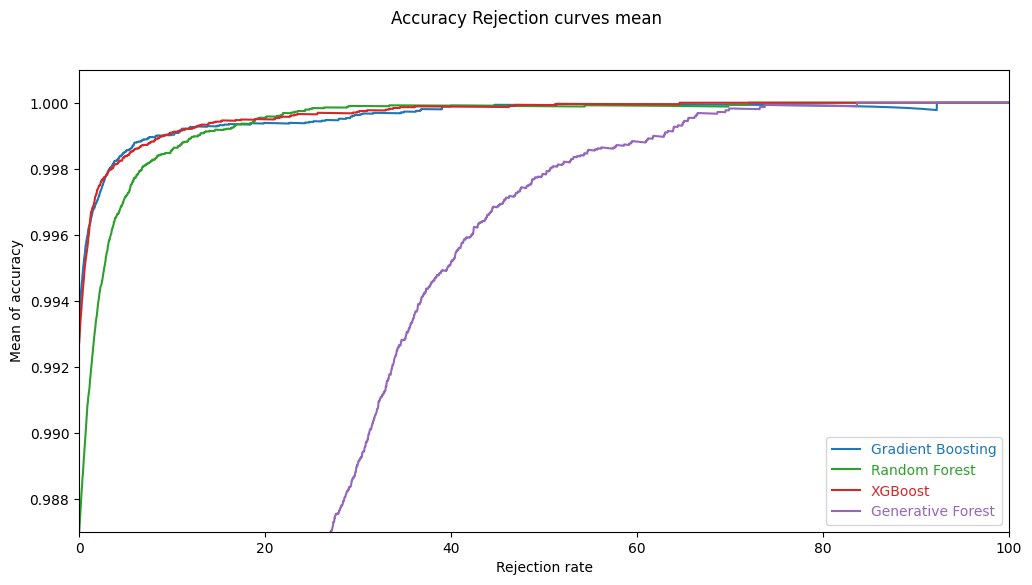

In [8]:
models_acc_rej(rob_measures = rob_mods['robot']["rob"], classification_results = rob_mods['robot']["class"],
               fig_size=(12,6), mean=True, show=True, y_min=0.987, legend_loc='lower right', AUC=True)



AUC:  0.8983142445182943

AUC:  0.8959775695088688

AUC:  0.8983560197684628

AUC:  0.8129798450927528


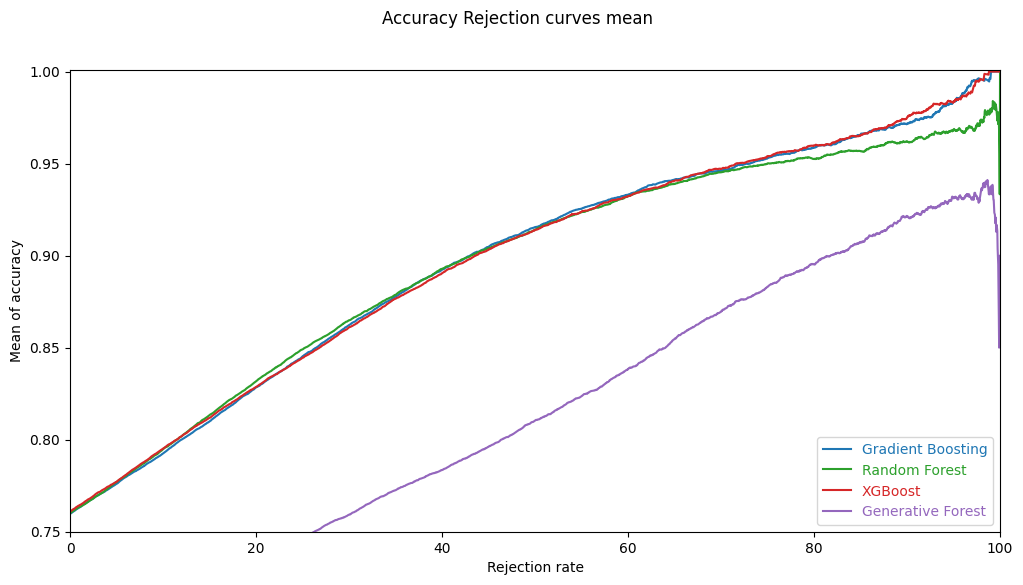

In [7]:
models_acc_rej(rob_measures = rob_mods['students']["rob"], classification_results = rob_mods['students']["class"],
               fig_size=(12,6), mean=True, show=True, y_min=0.75, legend_loc='lower right', AUC=True)